In [1]:
# ============================================================
# PHASE 1: IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# ============================================================
# PHASE 2A: CHECK FILES IN DATASET FOLDER
# ============================================================

import os

data_folder = r"C:\Users\spand\Desktop\mini projects\Concrete Compressive Strength Prediction project\data set"

print("Files available in dataset folder:\n")

for file in os.listdir(data_folder):
    print(file)

Files available in dataset folder:

Concrete_Data.xls
Concrete_Readme.txt


In [3]:
# ============================================================
# PHASE 2B: LOAD EXCEL DATASET
# ============================================================

file_path = r"C:\Users\spand\Desktop\mini projects\Concrete Compressive Strength Prediction project\data set\Concrete_Data.xls"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

ImportError: `Import xlrd` failed. Install xlrd >= 2.0.1 for xls Excel support Use pip or conda to install the xlrd package.

In [4]:
!pip install xlrd

In [5]:
import pandas as pd

file_path = r"C:\Users\spand\Desktop\mini projects\Concrete Compressive Strength Prediction project\data set\Concrete_Data.xls"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (1030, 9)


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [6]:
import sys
!{sys.executable} -m pip install xlrd

In [7]:
df = pd.read_excel(
    r"C:\Users\spand\Desktop\mini projects\Concrete Compressive Strength Prediction project\data set\Concrete_Data.xls",
    engine="xlrd"
)

print(df.shape)
print(df.columns.tolist())

display(df.head())

(1030, 9)
['Cement (component 1)(kg in a m^3 mixture)', 'Blast Furnace Slag (component 2)(kg in a m^3 mixture)', 'Fly Ash (component 3)(kg in a m^3 mixture)', 'Water  (component 4)(kg in a m^3 mixture)', 'Superplasticizer (component 5)(kg in a m^3 mixture)', 'Coarse Aggregate  (component 6)(kg in a m^3 mixture)', 'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)', 'Concrete compressive strength(MPa, megapascals) ']


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [8]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
for i, col in enumerate(df.columns):
    print(i, ":", col)

print("\nFirst 5 rows:")
display(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (1030, 9)

Column Names:
0 : Cement (component 1)(kg in a m^3 mixture)
1 : Blast Furnace Slag (component 2)(kg in a m^3 mixture)
2 : Fly Ash (component 3)(kg in a m^3 mixture)
3 : Water  (component 4)(kg in a m^3 mixture)
4 : Superplasticizer (component 5)(kg in a m^3 mixture)
5 : Coarse Aggregate  (component 6)(kg in a m^3 mixture)
6 : Fine Aggregate (component 7)(kg in a m^3 mixture)
7 : Age (day)
8 : Concrete compressive strength(MPa, megapascals) 

First 5 rows:


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075



Missing Values:
Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)      0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0
Age (day)                                                0
Concrete compressive strength(MPa, megapascals)          0
dtype: int64

Duplicate Rows:
25


In [9]:
# ============================================================
# PHASE 3: UNDERSTAND THE DATASET
# ============================================================

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 1030
Number of Columns: 9


In [10]:
print("Column Names:")
print("=" * 60)

for i, column in enumerate(df.columns):
    print(i + 1, ":", column)

Column Names:
1 : Cement (component 1)(kg in a m^3 mixture)
2 : Blast Furnace Slag (component 2)(kg in a m^3 mixture)
3 : Fly Ash (component 3)(kg in a m^3 mixture)
4 : Water  (component 4)(kg in a m^3 mixture)
5 : Superplasticizer (component 5)(kg in a m^3 mixture)
6 : Coarse Aggregate  (component 6)(kg in a m^3 mixture)
7 : Fine Aggregate (component 7)(kg in a m^3 mixture)
8 : Age (day)
9 : Concrete compressive strength(MPa, megapascals) 


In [11]:
# ============================================================
# PHASE 4: DATA INFORMATION
# ============================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   Concrete compressive strength(MPa, megapascals)        1030 

In [12]:
# ============================================================
# PHASE 5: MISSING VALUE ANALYSIS
# ============================================================

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)      0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0
Age (day)                                                0
Concrete compressive strength(MPa, megapascals)          0
dtype: int64


In [13]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

display(missing_table)

,Missing Count,Missing Percentage
Cement (component 1)(kg in a m^3 mixture),0,0.0
Blast Furnace Slag (component 2)(kg in a m^3 mixture),0,0.0
Fly Ash (component 3)(kg in a m^3 mixture),0,0.0
Water (component 4)(kg in a m^3 mixture),0,0.0
Superplasticizer (component 5)(kg in a m^3 mixture),0,0.0
Coarse Aggregate (component 6)(kg in a m^3 mixture),0,0.0
Fine Aggregate (component 7)(kg in a m^3 mixture),0,0.0
Age (day),0,0.0
"Concrete compressive strength(MPa, megapascals)",0,0.0


In [14]:
# ============================================================
# PHASE 6: DUPLICATE ANALYSIS
# ============================================================

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 25


In [15]:
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed.")
else:
    print("No duplicates found. Dataset remains unchanged.")

print("New dataset shape:", df.shape)

Duplicates removed.
New dataset shape: (1005, 9)


In [16]:
# ============================================================
# PHASE 7: STATISTICAL SUMMARY
# ============================================================

display(df.describe())

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000
mean,278.629055,72.043134,55.535075,182.074378,6.031647,974.376468,772.686617,45.856716,35.250273
std,104.345003,86.170555,64.207448,21.340740,5.919559,77.579534,80.339851,63.734692,16.284808
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,190.680000,0.000000,0.000000,166.610000,0.000000,932.000000,724.300000,7.000000,23.523542
50%,265.000000,20.000000,0.000000,185.700000,6.100000,968.000000,780.000000,28.000000,33.798114
75%,349.000000,142.500000,118.270000,192.940000,10.000000,1031.000000,822.200000,56.000000,44.868340
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


In [17]:
# ============================================================
# PHASE 8: DATA TYPE CHECK
# ============================================================

print(df.dtypes)

Cement (component 1)(kg in a m^3 mixture)                float64
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    float64
Fly Ash (component 3)(kg in a m^3 mixture)               float64
Water  (component 4)(kg in a m^3 mixture)                float64
Superplasticizer (component 5)(kg in a m^3 mixture)      float64
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     float64
Fine Aggregate (component 7)(kg in a m^3 mixture)        float64
Age (day)                                                  int64
Concrete compressive strength(MPa, megapascals)          float64
dtype: object


In [18]:
print(df.columns.tolist())

['Cement (component 1)(kg in a m^3 mixture)', 'Blast Furnace Slag (component 2)(kg in a m^3 mixture)', 'Fly Ash (component 3)(kg in a m^3 mixture)', 'Water  (component 4)(kg in a m^3 mixture)', 'Superplasticizer (component 5)(kg in a m^3 mixture)', 'Coarse Aggregate  (component 6)(kg in a m^3 mixture)', 'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)', 'Concrete compressive strength(MPa, megapascals) ']


In [19]:
# ============================================================
# PHASE 9: RENAME COLUMNS
# ============================================================

df.columns = [
    "Cement",
    "Blast_Furnace_Slag",
    "Fly_Ash",
    "Water",
    "Superplasticizer",
    "Coarse_Aggregate",
    "Fine_Aggregate",
    "Age",
    "Concrete_Strength"
]

print("Columns renamed successfully!")
print(df.columns.tolist())

Columns renamed successfully!
['Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Water', 'Superplasticizer', 'Coarse_Aggregate', 'Fine_Aggregate', 'Age', 'Concrete_Strength']


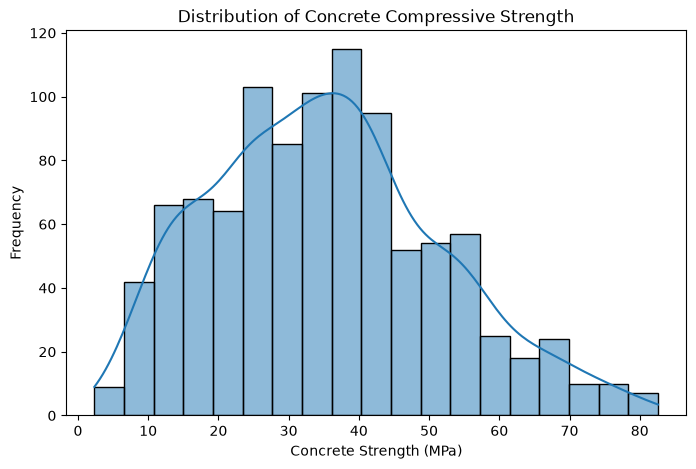

In [20]:
# ============================================================
# PHASE 10: TARGET DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    df["Concrete_Strength"],
    kde=True
)

plt.title("Distribution of Concrete Compressive Strength")
plt.xlabel("Concrete Strength (MPa)")
plt.ylabel("Frequency")

plt.show()

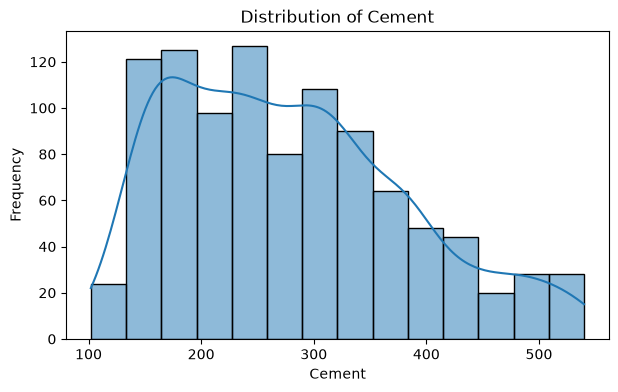

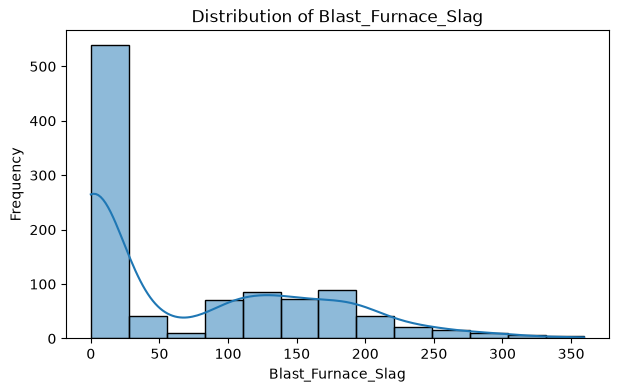

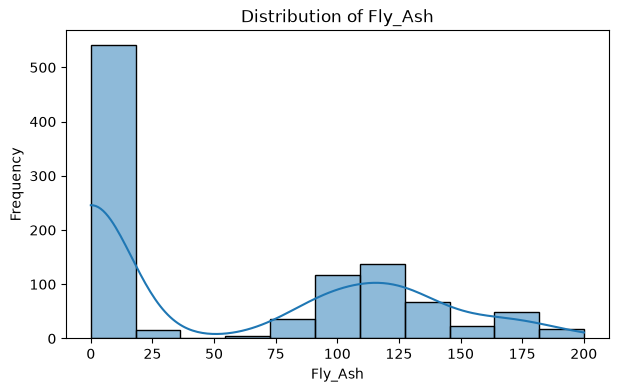

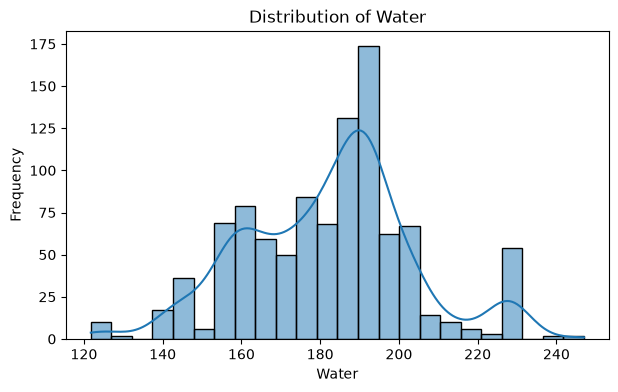

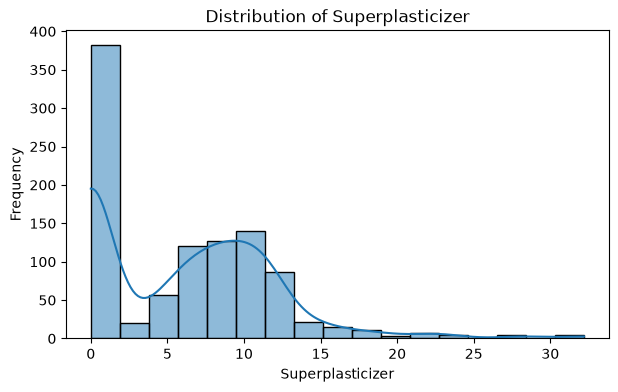

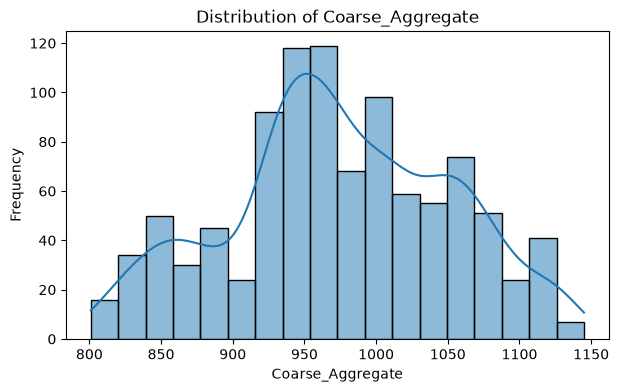

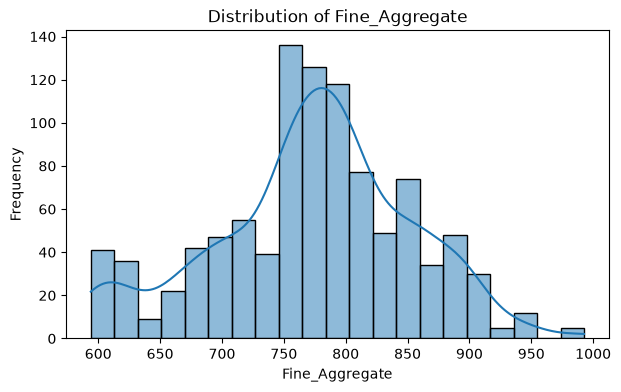

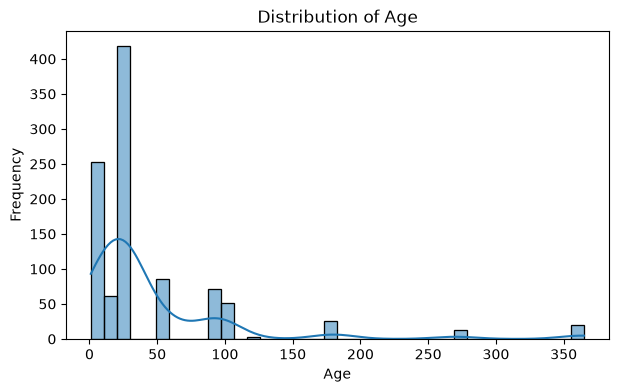

In [21]:
# ============================================================
# PHASE 11: FEATURE DISTRIBUTIONS
# ============================================================

features = [
    "Cement",
    "Blast_Furnace_Slag",
    "Fly_Ash",
    "Water",
    "Superplasticizer",
    "Coarse_Aggregate",
    "Fine_Aggregate",
    "Age"
]

for feature in features:

    plt.figure(figsize=(7, 4))

    sns.histplot(
        df[feature],
        kde=True
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.show()

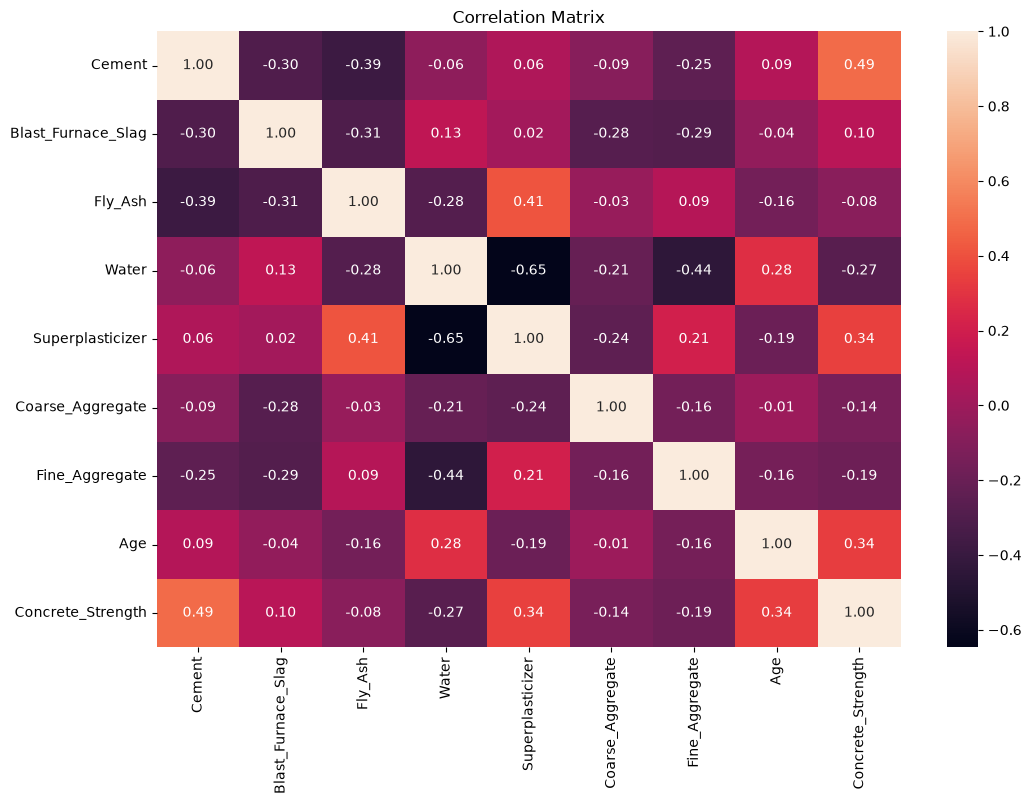

In [22]:
# ============================================================
# PHASE 12: CORRELATION MATRIX
# ============================================================

correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [23]:
# ============================================================
# PHASE 13: CORRELATION WITH TARGET
# ============================================================

target_correlation = (
    df.corr(numeric_only=True)["Concrete_Strength"]
    .sort_values(ascending=False)
)

print("Correlation with Concrete Strength:")
display(target_correlation)

Correlation with Concrete Strength:


Concrete_Strength     1.000000
Cement                0.488283
Superplasticizer      0.344225
Age                   0.337371
Blast_Furnace_Slag    0.103370
Fly_Ash              -0.080648
Coarse_Aggregate     -0.144710
Fine_Aggregate       -0.186457
Water                -0.269606
Name: Concrete_Strength, dtype: float64

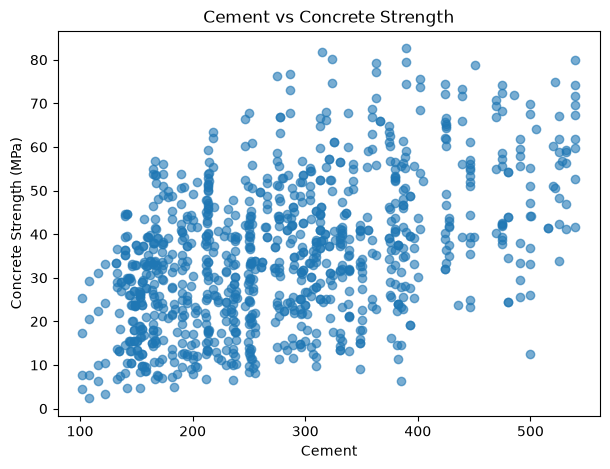

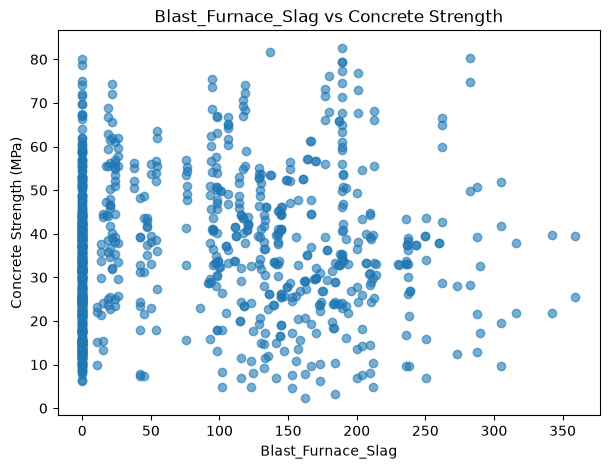

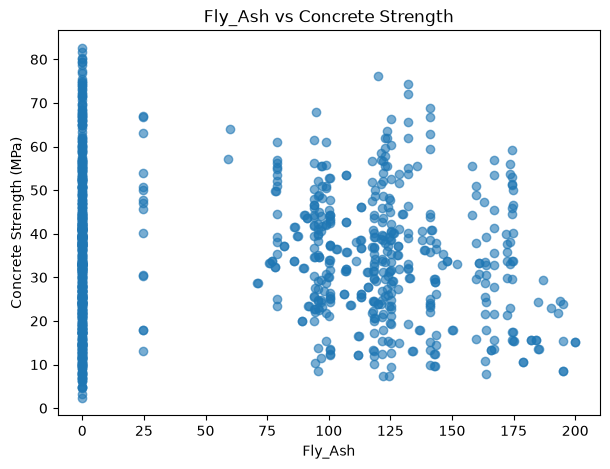

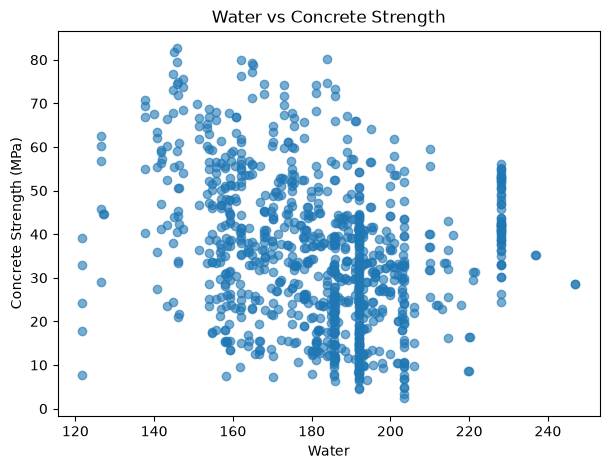

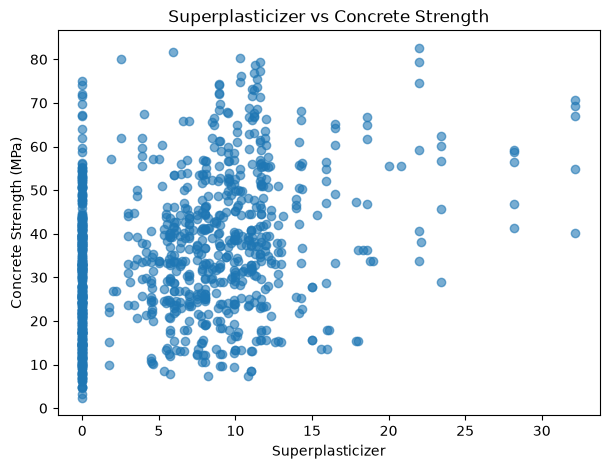

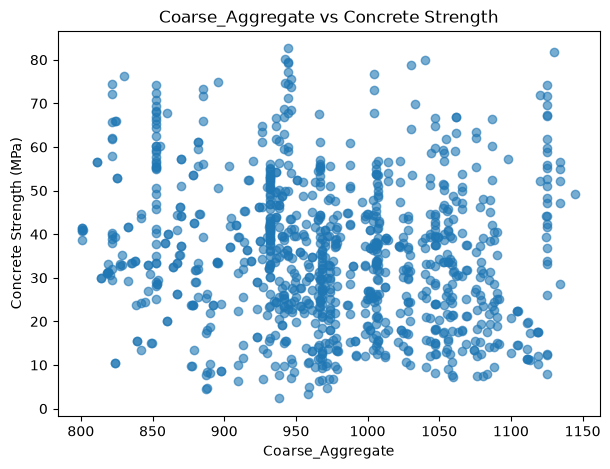

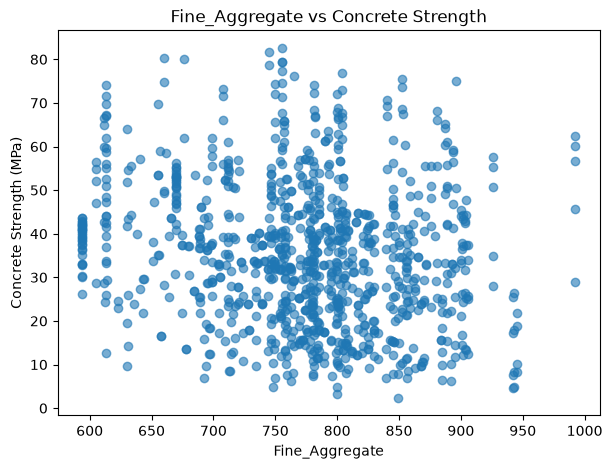

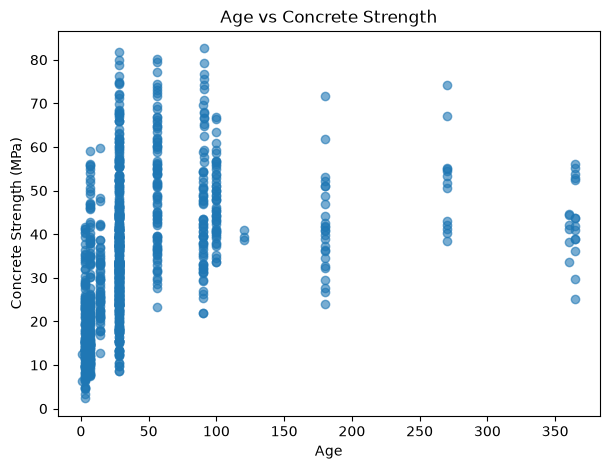

In [24]:
# ============================================================
# PHASE 14: SCATTER PLOTS
# ============================================================

for feature in features:

    plt.figure(figsize=(7, 5))

    plt.scatter(
        df[feature],
        df["Concrete_Strength"],
        alpha=0.6
    )

    plt.title(f"{feature} vs Concrete Strength")
    plt.xlabel(feature)
    plt.ylabel("Concrete Strength (MPa)")

    plt.show()

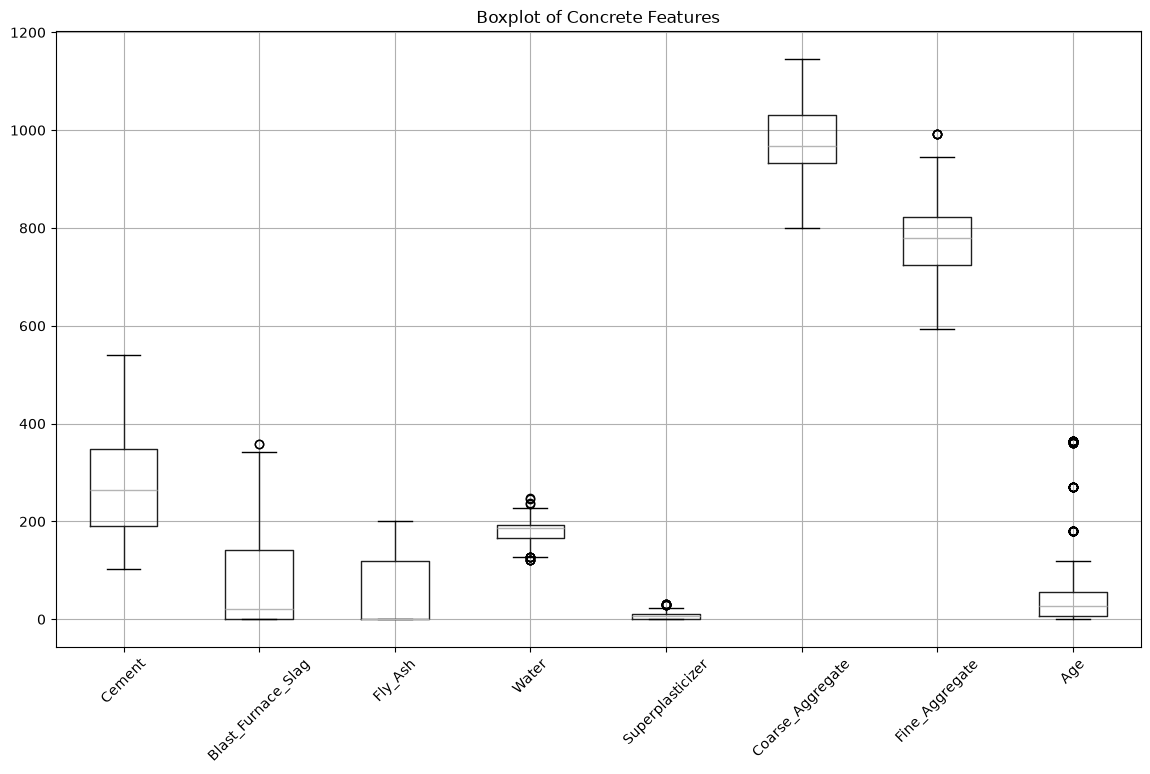

In [25]:
# ============================================================
# PHASE 15: OUTLIER INSPECTION
# ============================================================

plt.figure(figsize=(14, 8))

df[features].boxplot()

plt.title("Boxplot of Concrete Features")
plt.xticks(rotation=45)

plt.show()

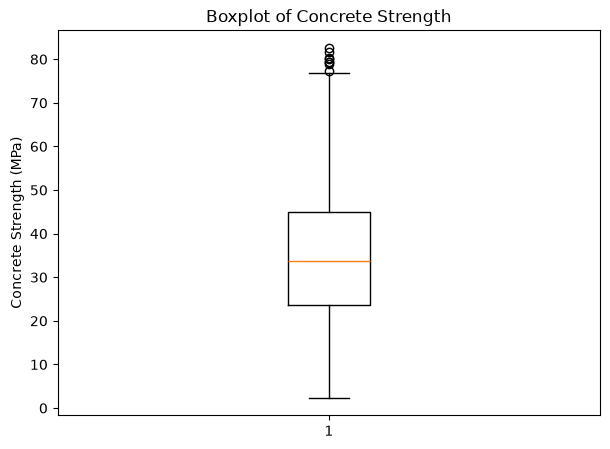

In [26]:
plt.figure(figsize=(7, 5))

plt.boxplot(df["Concrete_Strength"])

plt.title("Boxplot of Concrete Strength")
plt.ylabel("Concrete Strength (MPa)")

plt.show()

In [27]:
# ============================================================
# PHASE 17: SEPARATE INPUTS AND TARGET
# ============================================================

X = df[features]

y = df["Concrete_Strength"]

print("Input features (X):")
display(X.head())

print("\nTarget (y):")
display(y.head())

Input features (X):


,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360



Target (y):


0    79.986111
1    61.887366
2    40.269535
3    41.052780
4    44.296075
Name: Concrete_Strength, dtype: float64

In [28]:
# ============================================================
# PHASE 18: TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (804, 8)
Testing data: (201, 8)


In [29]:
# ============================================================
# PHASE 19: FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [30]:
# ============================================================
# PHASE 20: EVALUATION FUNCTION
# ============================================================

def evaluate_model(model_name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, y_pred)

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

In [31]:
# ============================================================
# PHASE 21: LINEAR REGRESSION
# ============================================================

linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

linear_pred = linear_model.predict(
    X_test_scaled
)

linear_result = evaluate_model(
    "Linear Regression",
    y_test,
    linear_pred
)

Linear Regression
MAE  : 8.8960
MSE  : 125.2653
RMSE : 11.1922
R²   : 0.5801


In [32]:
# ============================================================
# PHASE 22: POLYNOMIAL REGRESSION
# ============================================================

polynomial_model = Pipeline([
    (
        "poly",
        PolynomialFeatures(degree=2)
    ),
    (
        "linear",
        LinearRegression()
    )
])

polynomial_model.fit(
    X_train_scaled,
    y_train
)

polynomial_pred = polynomial_model.predict(
    X_test_scaled
)

polynomial_result = evaluate_model(
    "Polynomial Regression",
    y_test,
    polynomial_pred
)

Polynomial Regression
MAE  : 6.2205
MSE  : 69.0364
RMSE : 8.3088
R²   : 0.7686


In [33]:
# ============================================================
# PHASE 23: DECISION TREE REGRESSOR
# ============================================================

decision_tree_model = DecisionTreeRegressor(
    random_state=42
)

decision_tree_model.fit(
    X_train,
    y_train
)

decision_tree_pred = decision_tree_model.predict(
    X_test
)

decision_tree_result = evaluate_model(
    "Decision Tree Regressor",
    y_test,
    decision_tree_pred
)

Decision Tree Regressor
MAE  : 3.8635
MSE  : 40.7287
RMSE : 6.3819
R²   : 0.8635


In [34]:
# ============================================================
# PHASE 24: RANDOM FOREST REGRESSOR
# ============================================================

random_forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

random_forest_model.fit(
    X_train,
    y_train
)

random_forest_pred = random_forest_model.predict(
    X_test
)

random_forest_result = evaluate_model(
    "Random Forest Regressor",
    y_test,
    random_forest_pred
)

Random Forest Regressor
MAE  : 3.4756
MSE  : 26.1403
RMSE : 5.1128
R²   : 0.9124


In [35]:
# ============================================================
# PHASE 25: SUPPORT VECTOR REGRESSION
# ============================================================

svr_model = SVR(
    kernel="rbf",
    C=100,
    gamma="scale"
)

svr_model.fit(
    X_train_scaled,
    y_train
)

svr_pred = svr_model.predict(
    X_test_scaled
)

svr_result = evaluate_model(
    "Support Vector Regression",
    y_test,
    svr_pred
)

Support Vector Regression
MAE  : 4.0228
MSE  : 35.7185
RMSE : 5.9765
R²   : 0.8803


In [36]:
# ============================================================
# PHASE 26: GRADIENT BOOSTING REGRESSOR
# ============================================================

gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_boosting_model.fit(
    X_train,
    y_train
)

gradient_boosting_pred = gradient_boosting_model.predict(
    X_test
)

gradient_boosting_result = evaluate_model(
    "Gradient Boosting Regressor",
    y_test,
    gradient_boosting_pred
)

Gradient Boosting Regressor
MAE  : 3.9969
MSE  : 29.5420
RMSE : 5.4353
R²   : 0.9010


In [37]:
# ============================================================
# PHASE 27: MODEL COMPARISON
# ============================================================

results = pd.DataFrame([
    linear_result,
    polynomial_result,
    decision_tree_result,
    random_forest_result,
    svr_result,
    gradient_boosting_result
])

results = results.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

display(results)

,Model,MAE,MSE,RMSE,R2
0,Random Forest Regressor,3.475579,26.140308,5.112759,0.912377
1,Gradient Boosting Regressor,3.996894,29.541972,5.435253,0.900975
2,Support Vector Regression,4.022780,35.718511,5.976497,0.880271
3,Decision Tree Regressor,3.863461,40.728668,6.381902,0.863477
4,Polynomial Regression,6.220534,69.036432,8.308817,0.768589
5,Linear Regression,8.896028,125.265338,11.192200,0.580109


In [38]:
# ============================================================
# PHASE 28: BEST MODEL
# ============================================================

best_model_name = results.iloc[0]["Model"]

print("Best Model based on RMSE:")
print(best_model_name)

Best Model based on RMSE:
Random Forest Regressor


In [39]:
# ============================================================
# PHASE 29: STORE ALL PREDICTIONS
# ============================================================

predictions = {
    "Linear Regression": linear_pred,
    "Polynomial Regression": polynomial_pred,
    "Decision Tree Regressor": decision_tree_pred,
    "Random Forest Regressor": random_forest_pred,
    "Support Vector Regression": svr_pred,
    "Gradient Boosting Regressor": gradient_boosting_pred
}

best_predictions = predictions[best_model_name]

print("Best model:", best_model_name)

Best model: Random Forest Regressor


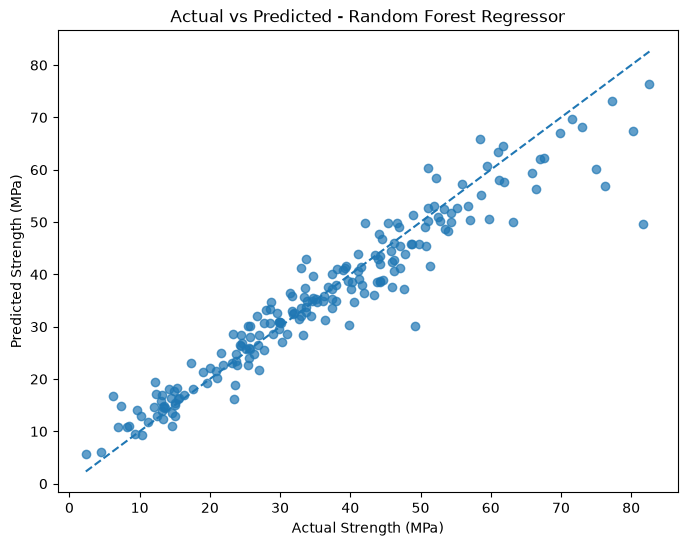

In [40]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.7
)

min_value = min(
    y_test.min(),
    best_predictions.min()
)

max_value = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Strength (MPa)")
plt.ylabel("Predicted Strength (MPa)")

plt.title(
    f"Actual vs Predicted - {best_model_name}"
)

plt.show()

In [41]:
# ============================================================
# PHASE 30: CALCULATE RESIDUALS
# ============================================================

residuals = y_test.values - best_predictions

print("First 10 residuals:")

for i in range(10):
    print(
        f"Actual: {y_test.values[i]:.2f}, "
        f"Predicted: {best_predictions[i]:.2f}, "
        f"Residual: {residuals[i]:.2f}"
    )

First 10 residuals:
Actual: 19.01, Predicted: 21.41, Residual: -2.40
Actual: 24.29, Predicted: 26.53, Residual: -2.24
Actual: 26.32, Predicted: 24.71, Residual: 1.62
Actual: 34.57, Predicted: 34.91, Residual: -0.34
Actual: 44.13, Predicted: 47.71, Residual: -3.58
Actual: 33.00, Predicted: 32.03, Residual: 0.97
Actual: 17.28, Predicted: 22.97, Residual: -5.70
Actual: 25.42, Predicted: 22.68, Residual: 2.74
Actual: 33.73, Predicted: 33.83, Residual: -0.10
Actual: 34.40, Predicted: 32.08, Residual: 2.32


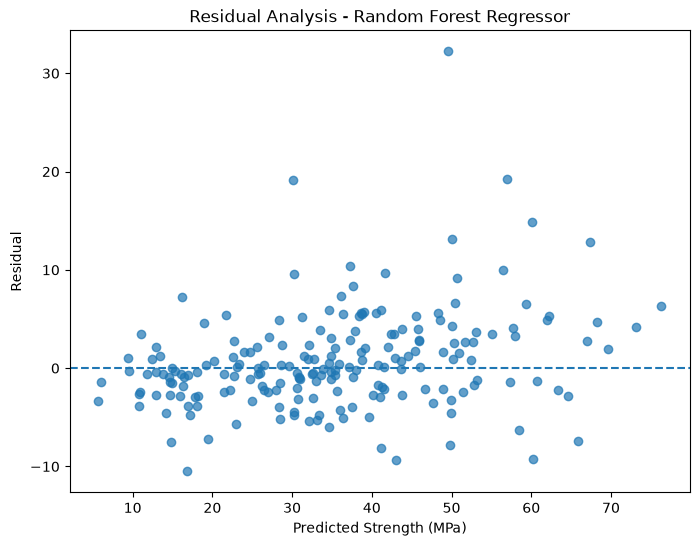

In [42]:
plt.figure(figsize=(8, 6))

plt.scatter(
    best_predictions,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Strength (MPa)")
plt.ylabel("Residual")

plt.title(
    f"Residual Analysis - {best_model_name}"
)

plt.show()

In [43]:
# ============================================================
# PHASE 31: HIGH-ERROR ANALYSIS
# ============================================================

error_analysis = pd.DataFrame({
    "Actual_Strength": y_test.values,
    "Predicted_Strength": best_predictions
})

error_analysis["Error"] = (
    error_analysis["Actual_Strength"]
    - error_analysis["Predicted_Strength"]
)

error_analysis["Absolute_Error"] = (
    error_analysis["Error"].abs()
)

high_error_samples = error_analysis.sort_values(
    by="Absolute_Error",
    ascending=False
)

display(high_error_samples.head(10))

,Actual_Strength,Predicted_Strength,Error,Absolute_Error
188,81.751169,49.537682,32.213487,32.213487
56,76.235361,56.952717,19.282644,19.282644
11,49.249271,30.113402,19.135869,19.135869
48,74.987410,60.107247,14.880163,14.880163
97,63.142212,50.030985,13.111227,13.111227
187,80.199848,67.324409,12.875439,12.875439
130,6.267337,16.780817,-10.513480,10.513480
42,47.711739,37.291220,10.420519,10.420519
114,66.424118,56.415960,10.008158,10.008158
95,51.331488,41.630847,9.700641,9.700641


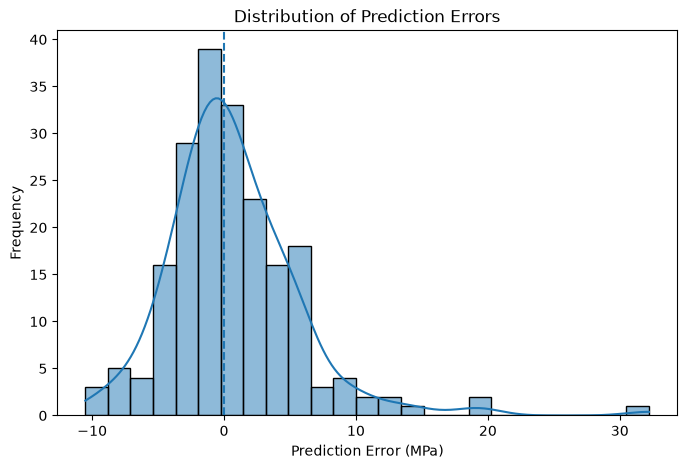

In [44]:
plt.figure(figsize=(8, 5))

sns.histplot(
    error_analysis["Error"],
    kde=True
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error (MPa)")
plt.ylabel("Frequency")

plt.show()

In [45]:
# ============================================================
# PHASE 33: FINAL PERFORMANCE TABLE
# ============================================================

print("FINAL MODEL COMPARISON")
print("=" * 80)

display(
    results.style.format({
        "MAE": "{:.4f}",
        "MSE": "{:.4f}",
        "RMSE": "{:.4f}",
        "R2": "{:.4f}"
    })
)

FINAL MODEL COMPARISON


,Model,MAE,MSE,RMSE,R2
0,Random Forest Regressor,3.4756,26.1403,5.1128,0.9124
1,Gradient Boosting Regressor,3.9969,29.5420,5.4353,0.9010
2,Support Vector Regression,4.0228,35.7185,5.9765,0.8803
3,Decision Tree Regressor,3.8635,40.7287,6.3819,0.8635
4,Polynomial Regression,6.2205,69.0364,8.3088,0.7686
5,Linear Regression,8.8960,125.2653,11.1922,0.5801


In [46]:
# ============================================================
# PHASE 34: SELECT ACTUAL BEST MODEL OBJECT
# ============================================================

model_objects = {
    "Linear Regression": linear_model,
    "Polynomial Regression": polynomial_model,
    "Decision Tree Regressor": decision_tree_model,
    "Random Forest Regressor": random_forest_model,
    "Support Vector Regression": svr_model,
    "Gradient Boosting Regressor": gradient_boosting_model
}

best_model = model_objects[best_model_name]

print("Selected model:")
print(best_model_name)

Selected model:
Random Forest Regressor


In [47]:
scaler_path = r"C:\Users\spand\Desktop\mini projects\Concrete Compressive Strength Prediction project\concrete_scaler.pkl"

joblib.dump(
    scaler,
    scaler_path
)

print("Scaler saved successfully!")
print(scaler_path)

Scaler saved successfully!
C:\Users\spand\Desktop\mini projects\Concrete Compressive Strength Prediction project\concrete_scaler.pkl


In [48]:
# ============================================================
# PHASE 36: EXPORT PREDICTIONS
# ============================================================

final_predictions = pd.DataFrame({
    "Actual_Strength_MPa": y_test.values,
    "Predicted_Strength_MPa": best_predictions
})

final_predictions["Error_MPa"] = (
    final_predictions["Actual_Strength_MPa"]
    - final_predictions["Predicted_Strength_MPa"]
)

final_predictions["Absolute_Error_MPa"] = (
    final_predictions["Error_MPa"].abs()
)

output_path = r"C:\Users\spand\Desktop\mini projects\Concrete Compressive Strength Prediction project\concrete_prediction_results.xlsx"

final_predictions.to_excel(
    output_path,
    index=False
)

print("Prediction results exported successfully!")
print(output_path)

Prediction results exported successfully!
C:\Users\spand\Desktop\mini projects\Concrete Compressive Strength Prediction project\concrete_prediction_results.xlsx


In [49]:
# ============================================================
# PHASE 37: NEW CONCRETE PREDICTION
# ============================================================

new_concrete = pd.DataFrame({
    "Cement": [350],
    "Blast_Furnace_Slag": [100],
    "Fly_Ash": [50],
    "Water": [180],
    "Superplasticizer": [10],
    "Coarse_Aggregate": [1000],
    "Fine_Aggregate": [700],
    "Age": [28]
})

display(new_concrete)

,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age
0,350,100,50,180,10,1000,700,28


In [50]:
new_prediction = best_model.predict(new_concrete)

print(
    "Predicted Concrete Compressive Strength:",
    round(new_prediction[0], 2),
    "MPa"
)

Predicted Concrete Compressive Strength: 49.32 MPa


In [51]:
pip install streamlit joblib

Note: you may need to restart the kernel to use updated packages.


In [52]:
!pip install streamlit joblib

In [55]:
# ============================================================
# SAVE THE BEST TRAINED MODEL
# ============================================================

import joblib

project_folder = r"C:\Users\spand\Desktop\mini projects\Concrete Compressive Strength Prediction project"

# Make sure the best model is selected
model_objects = {
    "Linear Regression": linear_model,
    "Polynomial Regression": polynomial_model,
    "Decision Tree Regressor": decision_tree_model,
    "Random Forest Regressor": random_forest_model,
    "Support Vector Regression": svr_model,
    "Gradient Boosting Regressor": gradient_boosting_model
}

best_model = model_objects[best_model_name]

# Save the model
model_path = project_folder + r"\best_concrete_strength_model.pkl"

joblib.dump(best_model, model_path)

print("Best model saved successfully!")
print("Best model:", best_model_name)
print("Saved location:", model_path)

Best model saved successfully!
Best model: Random Forest Regressor
Saved location: C:\Users\spand\Desktop\mini projects\Concrete Compressive Strength Prediction project\best_concrete_strength_model.pkl


In [56]:
import os

project_folder = r"C:\Users\spand\Desktop\mini projects\Concrete Compressive Strength Prediction project"

print("Files in project folder:\n")

for file in os.listdir(project_folder):
    print(file)

Files in project folder:

.ipynb_checkpoints
app.py
best_concrete_strength_model.pkl
concrete.ipynb
concrete_prediction_results.xlsx
concrete_scaler.pkl
data set
